In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Check what's actually in your Drive first, if you're not sure of the exact path
!ls "/content/drive/MyDrive/" | grep -i apple

appledataset.zip


In [3]:
!cp "/content/drive/MyDrive/appledataset.zip" /content/apple_dataset.zip
!unzip -q /content/apple_dataset.zip -d /content/apple_dataset

In [4]:
!find /content/apple_dataset -maxdepth 4 | head -40

/content/apple_dataset
/content/apple_dataset/test
/content/apple_dataset/test/dataset2_back_0.png
/content/apple_dataset/test/dataset1_front_541.png
/content/apple_dataset/test/dataset4_front_1110.png
/content/apple_dataset/test/dataset4_front_900.png
/content/apple_dataset/test/dataset4_front_1200.png
/content/apple_dataset/test/_MG_8971_13.jpg
/content/apple_dataset/test/dataset3_front_300.png
/content/apple_dataset/test/dataset3_front_780.png
/content/apple_dataset/test/dataset1_front_301.png
/content/apple_dataset/test/dataset3_front_1050.png
/content/apple_dataset/test/dataset2_back_390.png
/content/apple_dataset/test/dataset2_back_1260.png
/content/apple_dataset/test/dataset2_back_90.png
/content/apple_dataset/test/dataset2_back_1320.png
/content/apple_dataset/test/dataset1_front_691.png
/content/apple_dataset/test/dataset2_front_810.png
/content/apple_dataset/test/dataset2_back_180.png
/content/apple_dataset/test/dataset2_front_1230.png
/content/apple_dataset/test/dataset1_back

In [5]:
!cat /content/apple_dataset/data.yaml

cat: /content/apple_dataset/data.yaml: No such file or directory


In [6]:
import os

BASE = '/content/apple_dataset'

print("--- Folder structure ---")
for root, dirs, files in os.walk(BASE):
    depth = root.replace(BASE, '').count(os.sep)
    if depth > 2:
        continue
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth == 2:
        sample_files = files[:3]
        for f in sample_files:
            print(f"{indent}  {f}")

--- Folder structure ---
apple_dataset/
  test/
    .ipynb_checkpoints/
      _MG_3004_11-checkpoint.jpg
      _MG_3004_06-checkpoint.jpg
      _MG_3004_01-checkpoint.jpg
  train/
    .ipynb_checkpoints/
      _MG_3004_02-checkpoint.jpg
    yolo_labels/
      _MG_3004_17.txt
      _MG_8993_17.txt
      20150921_131453_image21.txt


In [7]:
train_files = os.listdir("/content/apple_dataset/train")
print(train_files[:20])
print(f"\n total items in train /: {len(train_files)}")

['_MG_8071_09.jpg', '_MG_8065_19.jpg', '20150921_131453_image731.png', '_MG_8903_19.jpg', '20150921_131833_image526.png', '_MG_7954_02.jpg', '20150919_174151_image106.png', '20150921_131833_image121.png', '20150921_131833_image336.png', '20150919_174730_image86.png', '20150921_132038_image1441.png', '20150921_131346_image816.png', '20150919_174151_image156.png', '20150921_132038_image46.png', '20150921_131833_image96.png', '20150921_131453_image646.png', '20150919_174730_image31.png', '20150921_131453_image801.png', '20150921_131346_image701.png', '20150921_131729_image171.png']

 total items in train /: 903


In [8]:
import os
import shutil
import random

BASE = '/content/apple_dataset'
SRC_IMAGES = f'{BASE}/train'
SRC_LABELS = f'{BASE}/train/yolo_labels'
DATASET_DIR = f'{BASE}/dataset'

for split in ['train', 'val']:
    os.makedirs(f'{DATASET_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{DATASET_DIR}/labels/{split}', exist_ok=True)

image_files = sorted([f for f in os.listdir(SRC_IMAGES)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                       and os.path.isfile(os.path.join(SRC_IMAGES, f))])

print(f"Total valid images found: {len(image_files)}")

random.seed(42)
random.shuffle(image_files)

split_idx = int(len(image_files) * 0.8)
train_files = image_files[:split_idx]
val_files = image_files[split_idx:]

def place_files(files, split):
    for img_name in files:
        base_name = os.path.splitext(img_name)[0]
        label_name = base_name + '.txt'

        shutil.copy(os.path.join(SRC_IMAGES, img_name),
                    f'{DATASET_DIR}/images/{split}/{img_name}')

        src_label = os.path.join(SRC_LABELS, label_name)
        if os.path.exists(src_label):
            shutil.copy(src_label, f'{DATASET_DIR}/labels/{split}/{label_name}')
        else:
            open(f'{DATASET_DIR}/labels/{split}/{label_name}', 'w').close()

place_files(train_files, 'train')
place_files(val_files, 'val')

print(f"Train: {len(train_files)} images | Val: {len(val_files)} images")

Total valid images found: 901
Train: 720 images | Val: 181 images


In [9]:
import yaml
yaml_content = {
    'path': f'{BASE}/dataset',
    'train': 'images/train',
    'val': 'images/val',
    'names': {0:'apple'}
}
with open(f'{BASE}/dataset/data.yaml','w') as f:
  yaml.dump(yaml_content, f)

print("data.yaml created")
!cat {BASE}/dataset/data.yaml

data.yaml created
names:
  0: apple
path: /content/apple_dataset/dataset
train: images/train
val: images/val


In [10]:
print("Train images:", len(os.listdir(f'{DATASET_DIR}/images/train')))
print("Train labels:", len(os.listdir(f'{DATASET_DIR}/labels/train')))
print("Val images:", len(os.listdir(f'{DATASET_DIR}/images/val')))
print("Val labels:", len(os.listdir(f'{DATASET_DIR}/labels/val')))

Train images: 720
Train labels: 720
Val images: 181
Val labels: 181


In [11]:
! pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.3 MB/s eta 0:00:00


In [12]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/apple_dataset/dataset/data.yaml',
    epochs=150,
    imgsz=320,
    batch=16,
    patience=20,
    device=0,
    project='apple_counter',
    name='yolov8n_apple_merged_v3',
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/apple_dataset/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, fl

In [13]:
metric = model.val()
print("map@5.0", metric.box.map50)
print("mAP@0.5:0.95",metric.box.map)

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4450.9±1451.2 MB/s, size: 1459.6 KB)
val: Scanning /content/apple_dataset/dataset/labels/val.cache... 181 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 181/181 54.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 2.6it/s 4.6s
                   all        181       6089       0.78      0.639      0.691      0.311
Speed: 0.8ms preprocess, 5.4ms inference, 0.0ms loss, 4.2ms postprocess per image
Results saved to /content/runs/detect/val
map@5.0 0.6911894501119501
mAP@0.5:0.95 0.31082353866007106


In [14]:
import matplotlib.pyplot as plt
import cv2
def predict(path,conf=0.1,iou=0.3):
  results = model(path, conf=conf, iou=iou)
  r=results[0]
  annoted = r.plot()
  plt.figure(figsize=(10,10))
  plt.imshow(cv2.cvtColor(annoted, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.title(f"Detected: {len(r.boxes)} apples")
  plt.show()


image 1/1 /content/apple_dataset/test/_MG_7954_09.jpg: 320x320 22 apples, 6.2ms
Speed: 1.1ms preprocess, 6.2ms inference, 1.5ms postprocess per image at shape (1, 3, 320, 320)


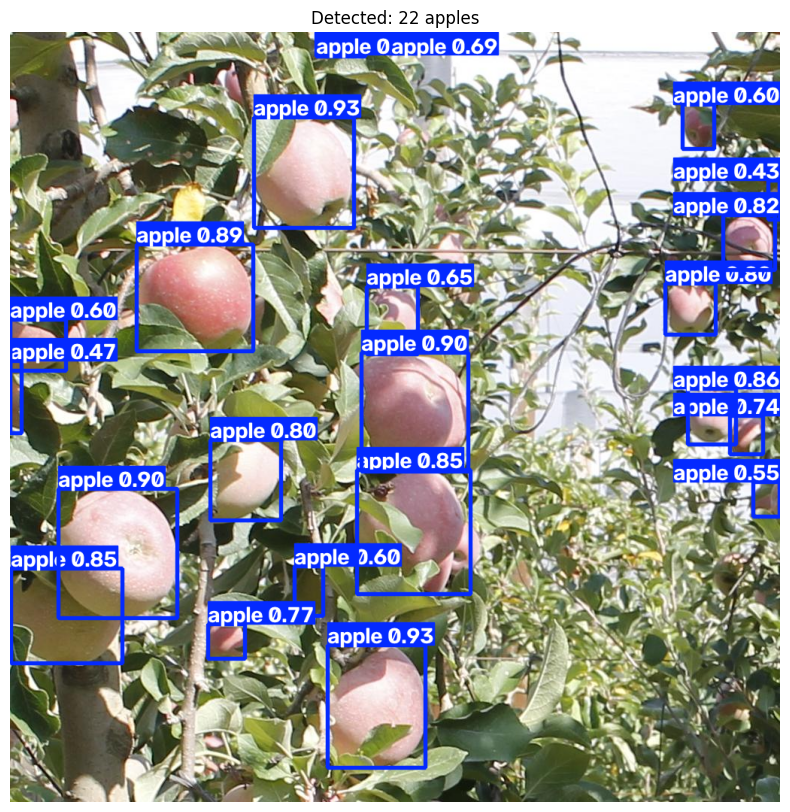

In [15]:
predict('/content/apple_dataset/test/_MG_7954_09.jpg',conf=0.4)


image 1/1 /content/apple_dataset/test/_MG_8915_07.jpg: 320x320 (no detections), 6.4ms
Speed: 1.3ms preprocess, 6.4ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 320)


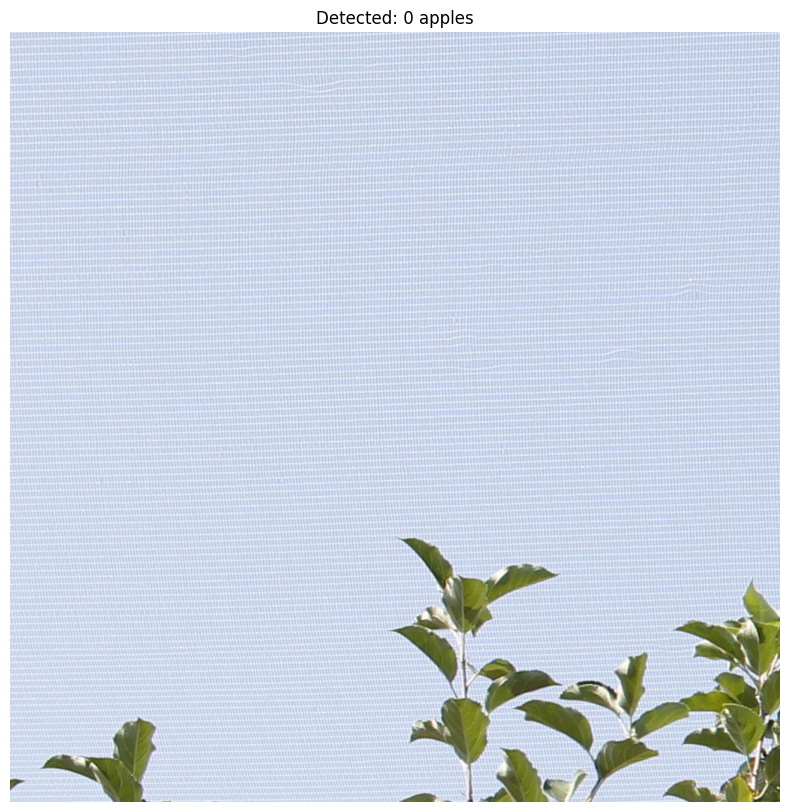

In [16]:
predict('/content/apple_dataset/test/_MG_8915_07.jpg')


image 1/1 /content/test img.jpg: 256x320 19 apples, 187.3ms
Speed: 7.7ms preprocess, 187.3ms inference, 3.0ms postprocess per image at shape (1, 3, 256, 320)


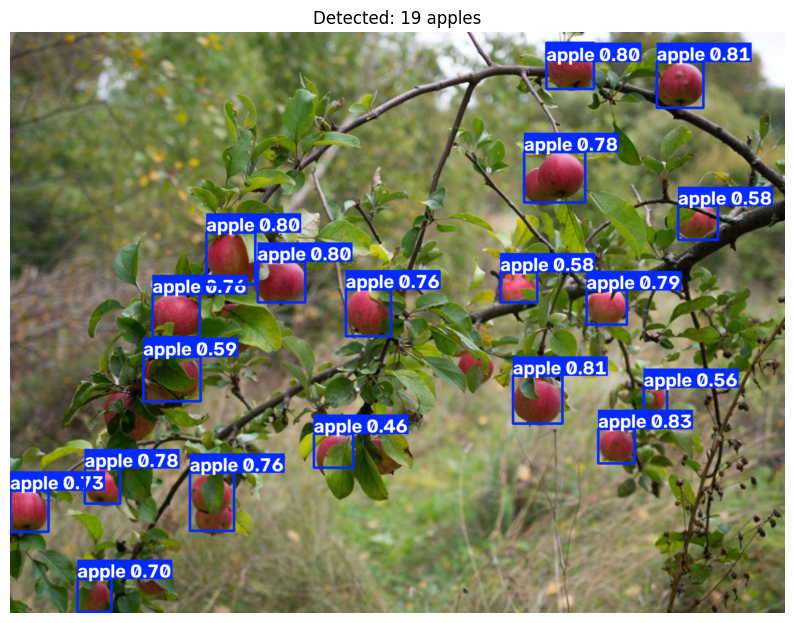

In [19]:
predict('/content/test img.jpg',conf=0.4)


image 1/1 /content/apple_dataset/test/_MG_8080_10.jpg: 320x320 13 apples, 17.4ms
Speed: 1.7ms preprocess, 17.4ms inference, 6.2ms postprocess per image at shape (1, 3, 320, 320)


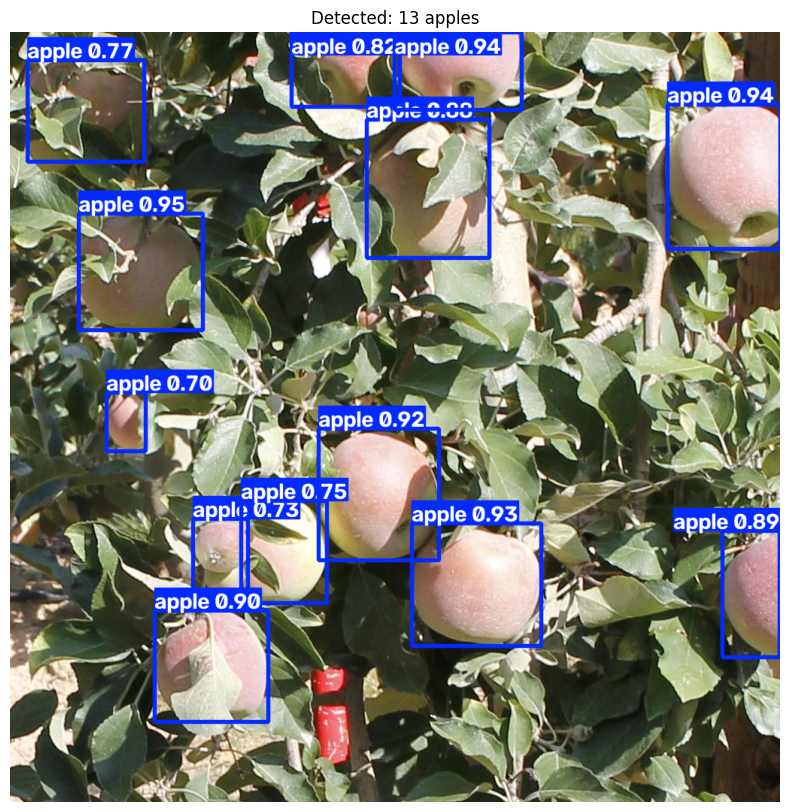

In [24]:
predict('/content/apple_dataset/test/_MG_8080_10.jpg',conf=0.4)

In [25]:
model.export(format='tflite', int8=True) # Export to TFLite format with int8 quantization

WARNING ⚠️ 'int8' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ format='tflite' is deprecated as of 8.4.83 and has been replaced by the unified Google LiteRT format. Exporting format='litert' instead. See https://docs.ultralytics.com/integrations/litert
Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ LiteRT INT8 export does not support end2end models, disabling end2end branch.
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 2.0 GFLOPs

PyTorch: starting from '/content/runs/detect/apple_counter/yolov8n_apple_merged_v3/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 5, 2100) (5.9 MB)
LiteRT: collecting INT8 ca

/usr/local/lib/python3.13/dist-packages/torchao/quantization/quant_api.py:1558: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.



LiteRT: starting export with litert_torch 0.9.4...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:00) [ DONE] Write Model to /content/runs/detect/apple_counter/yolov8n_apple_merged_v3/weights/best_int8.tflite 
(+00:00)

LiteRT: applying static quantization (int8 weights + int8 activations)...


/usr/local/lib/python3.13/dist-packages/ai_edge_litert/interpreter.py:480: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(
Applying Transformations to tensors:: 100%|██████████| 410/410 [00:00<00:00, 25823.89it/s]


Model name: /content/runs/detect/apple_counter/yolov8n_apple_merged_v3/weights/best_int8.tflite
Original model size: 11.61 MiB
Quantized model size: 3.15 MiB
Quantization Ratio: 0.27 (3.7x smaller)
Total time: 181.73 ms
LiteRT: export success ✅ 25.4s, saved as '/content/runs/detect/apple_counter/yolov8n_apple_merged_v3/weights/best_int8.tflite' (3.2 MB)

Export complete (25.6s)
Results saved to /content/runs/detect/apple_counter/yolov8n_apple_merged_v3/weights/best_int8.tflite
Predict:         yolo predict task=detect model=/content/runs/detect/apple_counter/yolov8n_apple_merged_v3/weights/best_int8.tflite imgsz=320 
Validate:        yolo val task=detect model=/content/runs/detect/apple_counter/yolov8n_apple_merged_v3/weights/best_int8.tflite imgsz=320 data=/content/apple_dataset/dataset/data.yaml  
Visualize:       https://netron.app


PosixPath('/content/runs/detect/apple_counter/yolov8n_apple_merged_v3/weights/best_int8.tflite')

In [27]:
from google.colab import files
files.download('/content/runs/detect/apple_counter/yolov8n_apple_merged_v3/weights/best_int8.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>